<a href="https://colab.research.google.com/github/ibuscio/taller_deeplearning/blob/main/Tarea_1_letra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 1 - Taller de Deep Learning

**Fecha de entrega:** 11/10/2026  
**Puntaje máximo:** 15 puntos  
**Alumno(s):**
- [Nombre1 y Apellido1]
- [Nombre2 y Apellido2]
- [Nombre3 y Apellido3]


## Introducción

El objetivo de esta tarea es evaluar su conocimiento sobre Deep Learning aplicado a un caso de uso real. En particular, vamos a evaluar la performance de sus modelos en una tarea de **clasificación de imágenes** con redes convolucionales.

### Dataset

El dataset a utilizar es **Imagewoof**, un subconjunto de ImageNet con 10 razas de perro difíciles de distinguir entre sí (Shih-Tzu, Rhodesian ridgeback, beagle, English foxhound, Border terrier, Australian terrier, golden retriever, Old English sheepdog, Samoyed y dingo). Pueden encontrar más información en el [repositorio oficial de fastai](https://github.com/fastai/imagenette#imagewoof).

**El dataset no está incluido en `torchvision.datasets`**. Parte de la tarea es que ustedes lo descarguen, lo descompriman y construyan el pipeline de carga (por ejemplo con `torchvision.datasets.ImageFolder` y un `DataLoader`). Tengan en cuenta que:

- El archivo `.tgz` contiene las carpetas `train/` y `val/`. Dentro de cada una hay una carpeta por clase, nombrada con su identificador de ImageNet (por ejemplo `n02086240`). Deben mapear esos identificadores a nombres legibles para el análisis y los reportes.
- El archivo `noisy_imagewoof.csv` incluido en el `.tgz` **no debe usarse** en esta tarea. Trabajen con las etiquetas dadas por las carpetas.
- La descarga y descompresión deben quedar en el notebook, de forma que quien corrija pueda reproducir todo el pipeline desde cero.

### Partición de datos

Imagewoof trae únicamente las particiones `train` y `val`. Para esta tarea:

- La partición `val` oficial se usa **únicamente como conjunto de test**, para reportar las métricas finales del modelo elegido.
- Deben separar un conjunto de **validación** a partir de `train`, y usarlo para tomar todas las decisiones de diseño (hiperparámetros, early stopping, selección de modelo, etc.).
- Ajustar hiperparámetros o seleccionar modelos usando el conjunto de test será penalizado.

### Tarea

Tienen total libertad sobre cómo implementar y resolver el problema, así como las técnicas y herramientas que quieran usar. Recomendamos usar Google Colab por simplicidad, pero pueden implementarlo en sus máquinas si así lo prefieren. La entrega debe realizarse en formato `.ipynb` (Jupyter Notebook) **con las celdas ya ejecutadas**.

### Restricciones

- No se permite utilizar modelos pre-entrenados; cada modelo debe ser implementado desde cero.
- Se requiere que utilicen al menos 2 técnicas de **regularización** (Dropout, BatchNorm, Data Augmentation, Weight Decay, etc.). Para cada técnica deben mostrar su efecto con una **ablación**: una corrida con la técnica y una corrida sin ella, con el resto de la configuración igual.
- Se requiere realizar un **análisis exploratorio de los datos**, que incluya la distribución de clases en `train` y `val`, los tamaños y resoluciones de las imágenes, y ejemplos visuales de cada clase. Las decisiones de preprocesamiento y de entrenamiento deben tomarse en base a ese análisis.
- Las decisiones sobre el preprocesamiento de las imágenes (transforms, augmentation, normalización, etc.) deben ser resultado de la exploración del dataset y estar justificadas en el notebook.
- Deben fijar una **semilla** para que los resultados sean reproducibles, y reportar el hardware utilizado (GPU/CPU) y el tiempo de entrenamiento de cada corrida.
- Pueden usar `utils.py` y todo el material dado en clase, siempre y cuando entiendan lo que están usando. Pueden ser consultados sobre cualquier parte del código entregado.

### Reporte

Deben reportar, sobre el conjunto de test, las siguientes métricas del modelo final:

- **Accuracy**.
- **Precision, recall y F1-score** con promedio **macro**.
- **Precision, recall y F1-score por clase**.
- **Matriz de confusión**, con un breve análisis de qué clases se confunden entre sí y por qué.

También se espera poder observar la evolución del modelo (loss y accuracy en train y validación) a medida que se entrena, mediante logs y gráficas.

### Evidencia de experimentos

Deben presentar evidencia de correr experimentos usando [Weights & Biases (wandb)](https://wandb.ai/). Esto incluye:

- Un **link público** al proyecto de wandb.
- Un mínimo de **5 experimentos** con configuraciones distintas (arquitectura, regularización, hiperparámetros, etc.). Las corridas de la ablación cuentan dentro de estos 5.
- Gráficas y logs de entrenamiento de cada corrida.
- Una **tabla resumen** en el notebook que compare las corridas: configuración, métricas en validación y tiempo de entrenamiento.
- Una justificación de cuál es el modelo final elegido y por qué.


## Formato de entrega

- La tarea se realiza en **grupos de 2 o 3 personas**.
- Se entrega este notebook con **todas las celdas ejecutadas**, junto con los archivos auxiliares que use (por ejemplo `utils.py`). **No se entregan ni los pesos de los modelos ni los datos**, pero el notebook debe poder ejecutarse de principio a fin con lo entregado (`Restart & Run All`), incluyendo la descarga del dataset.
- El notebook principal **no puede superar las 30 páginas** una vez exportado a PDF. Si necesitan más espacio para logs o gráficas secundarias, usen el link a wandb.
- Se recomienda seguir la estructura sugerida más abajo. Pueden agregar subsecciones, pero no eliminar secciones.

### Uso de herramientas de IA

Se permite el uso de herramientas de IA (ChatGPT, Copilot, Claude, etc.) como apoyo. Sin embargo:

- Los alumnos son **responsables de todo lo que entregan** y deben **entender** cada parte del código y del análisis. Pueden ser consultados sobre cualquier parte de la entrega.
- Se espera que apliquen los conocimientos vistos en clase para guiar y evaluar lo que estas herramientas producen. Un notebook que no refleje los contenidos del curso, o que contenga código que el grupo no puede explicar, puede penalizado.

### Rúbrica

| Ítem | Puntos |
|---|---|
| Carga del dataset y análisis exploratorio, con decisiones justificadas | 3 |
| Diseño del modelo, pipeline de entrenamiento y partición de datos correcta | 4 |
| Regularización | 3 |
| Evaluación en test, métricas y análisis de errores | 2 |
| Experimentos en wandb, tabla comparativa y conclusiones | 3 |
| **Total** | **15** |


---

## 1. Setup

_Imports, instalación de dependencias, semilla, dispositivo y login en wandb._

In [4]:
! pip install torchinfo

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Subset
from torchvision.transforms import v2 as T
from torchvision.io import read_image

from torchinfo import summary

import urllib.request
from pathlib import Path
import matplotlib.pyplot as plt

from utils import (
    train,
    plot_training,
    model_classification_report,
    show_tensor_image,
    show_tensor_images,
)

In [5]:
# Fijamos la semilla para que los resultados sean reproducibles
SEED = 23

torch.manual_seed(SEED)
# cuDNN elige algoritmos deterministas (mismo resultado en cada corrida, algo más lento)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [6]:
from utils import get_device, get_num_workers

DEVICE = get_device()  # cuda > mps > xpu > cpu
# Linux: mitad de los núcleos disponibles, entre 1 y 8; Windows/macOS: 0 (ver docstring)
NUM_WORKERS = get_num_workers()

print(f"Usando {DEVICE}")
print(f"Usando {NUM_WORKERS} workers")

Usando cpu
Usando 1 workers


In [ ]:
BATCH_SIZE = 64

## 2. Descarga y carga del dataset

_Descarga y descompresión de `imagewoof2-160.tgz`, mapeo de identificadores a nombres de clase, y construcción de los `Dataset`/`DataLoader`._

In [7]:
DATA_URL = 'https://s3.amazonaws.com/fast-ai-imageclas/imagewoof2-160.tgz'
DATA_PATH = Path('data')
DATA_PATH.mkdir(exist_ok=True)
ARCHIVE_PATH = DATA_PATH / 'imagewoof2-160.tgz'
EXTRACT_PATH = DATA_PATH / 'imagewoof2-160'

### Descarga del dataset

In [8]:
if not ARCHIVE_PATH.exists():
    print(f"Descargando {DATA_URL}...")
    urllib.request.urlretrieve(DATA_URL, ARCHIVE_PATH)
    print(f"Descarga completa en {ARCHIVE_PATH}")
else:
    print(f"El archivo {ARCHIVE_PATH} ya existe.")

Descargando https://s3.amazonaws.com/fast-ai-imageclas/imagewoof2-160.tgz...
Descarga completa en data/imagewoof2-160.tgz


### Descompresión del dataset

In [9]:
if not EXTRACT_PATH.exists():
    print(f"Descomprimiendo {ARCHIVE_PATH}...")
    !tar -xzf {ARCHIVE_PATH} -C {DATA_PATH}
    print(f"Descompresión completa en {EXTRACT_PATH}")
else:
    print(f"El directorio {EXTRACT_PATH} ya existe.")

Descomprimiendo data/imagewoof2-160.tgz...
Descompresión completa en data/imagewoof2-160


In [12]:
TRAIN_DATA_PATH = "data/imagewoof2-160/val"
VAL_DATA_PATH = "data/imagewoof2-160/val"

# Definimos el mapeo de los IDs de ImageNet a nombres de clases legibles para Imagewoof
IMAGENET_ID_TO_NAME = {
    'n02086240': 'Shih-Tzu',
    'n02099601': 'golden retriever',
    'n02088094': 'beagle',
    'n02096294': 'Australian terrier',
    'n02089973': 'English foxhound',
    'n02093754': 'Border terrier',
    'n02087394': 'Rhodesian ridgeback',
    'n02105641': 'Old English sheepdog',
    'n02111889': 'Samoyed',
    'n02113978': 'dingo'
}

# Creamos un mapeo inverso para comodidad si se necesita más tarde (por ejemplo, para etiquetas enteras)
NAME_TO_IMAGENET_ID = {name: id for id, name in IMAGENET_ID_TO_NAME.items()}

print("Rutas definidas para los datos de entrenamiento y test:")
print(f"TRAIN_DATA_PATH: {TRAIN_DATA_PATH}")
print(f"TEST_DATA_PATH: {VAL_DATA_PATH}")
print("\nMapeo de ID de ImageNet a nombre de clase:")
for id, name in IMAGENET_ID_TO_NAME.items():
    print(f"{id}: {name}")

Rutas definidas para los datos de entrenamiento y test:
TRAIN_DATA_PATH: data/imagewoof2-160/val
TEST_DATA_PATH: data/imagewoof2-160/val

Mapeo de ID de ImageNet a nombre de clase:
n02086240: Shih-Tzu
n02099601: golden retriever
n02088094: beagle
n02096294: Australian terrier
n02089973: English foxhound
n02093754: Border terrier
n02087394: Rhodesian ridgeback
n02105641: Old English sheepdog
n02111889: Samoyed
n02113978: dingo


## 3. Análisis exploratorio de datos

_Distribución de clases, tamaños y resoluciones de las imágenes, ejemplos visuales. Conclusiones que guían el preprocesamiento._

In [14]:
import os

# Obtener las clases (subdirectorios) en el TRAIN_DATA_PATH
class_dirs = [d for d in os.listdir(TRAIN_DATA_PATH) if os.path.isdir(os.path.join(TRAIN_DATA_PATH, d))]
class_counts = {}

print("Número de imágenes por clase en el directorio de entrenamiento:")
for class_id in sorted(class_dirs):
    class_path = os.path.join(TRAIN_DATA_PATH, class_id)
    num_images = len([f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))])
    class_name = IMAGENET_ID_TO_NAME.get(class_id, class_id) # Usar nombre legible si está disponible
    class_counts[class_name] = num_images
    print(f"  {class_name} ({class_id}): {num_images} imágenes")

total_train_images = sum(class_counts.values())
print(f"Total de imágenes en entrenamiento: {total_train_images}")

Número de imágenes por clase en el directorio de entrenamiento:
  Shih-Tzu (n02086240): 409 imágenes
  Rhodesian ridgeback (n02087394): 408 imágenes
  n02088364 (n02088364): 418 imágenes
  English foxhound (n02089973): 224 imágenes
  Border terrier (n02093754): 401 imágenes
  Australian terrier (n02096294): 407 imágenes
  golden retriever (n02099601): 401 imágenes
  Old English sheepdog (n02105641): 422 imágenes
  Samoyed (n02111889): 429 imágenes
  n02115641 (n02115641): 410 imágenes
Total de imágenes en entrenamiento: 3929


### Análisis de tamaños y resoluciones de imágenes

In [15]:
from PIL import Image
import numpy as np

image_sizes = []
num_samples = 500 # Limitar el número de muestras para evitar procesar todas las imágenes si es muy grande

# Recorrer un subconjunto de imágenes para recolectar sus tamaños
print(f"Analizando tamaños de imágenes (hasta {num_samples} muestras)...")
for class_id in sorted(class_dirs):
    class_path = os.path.join(TRAIN_DATA_PATH, class_id)
    images_in_class = [os.path.join(class_path, f) for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    for img_path in np.random.choice(images_in_class, min(len(images_in_class), num_samples // len(class_dirs)), replace=False):
        with Image.open(img_path) as img:
            image_sizes.append(img.size)

if image_sizes:
    widths = [s[0] for s in image_sizes]
    heights = [s[1] for s in image_sizes]

    print(f"Ancho mínimo: {min(widths)} px, Ancho máximo: {max(widths)} px")
    print(f"Alto mínimo: {min(heights)} px, Alto máximo: {max(heights)} px")
    print(f"Ancho promedio: {np.mean(widths):.2f} px, Alto promedio: {np.mean(heights):.2f} px")
    print(f"Todas las imágenes tienen el mismo tamaño: {len(set(image_sizes)) == 1}")
else:
    print("No se encontraron imágenes para analizar sus tamaños.")


Analizando tamaños de imágenes (hasta 500 muestras)...
Ancho mínimo: 160 px, Ancho máximo: 359 px
Alto mínimo: 160 px, Alto máximo: 287 px
Ancho promedio: 203.51 px, Alto promedio: 171.53 px
Todas las imágenes tienen el mismo tamaño: False


### Ejemplos visuales de cada clase

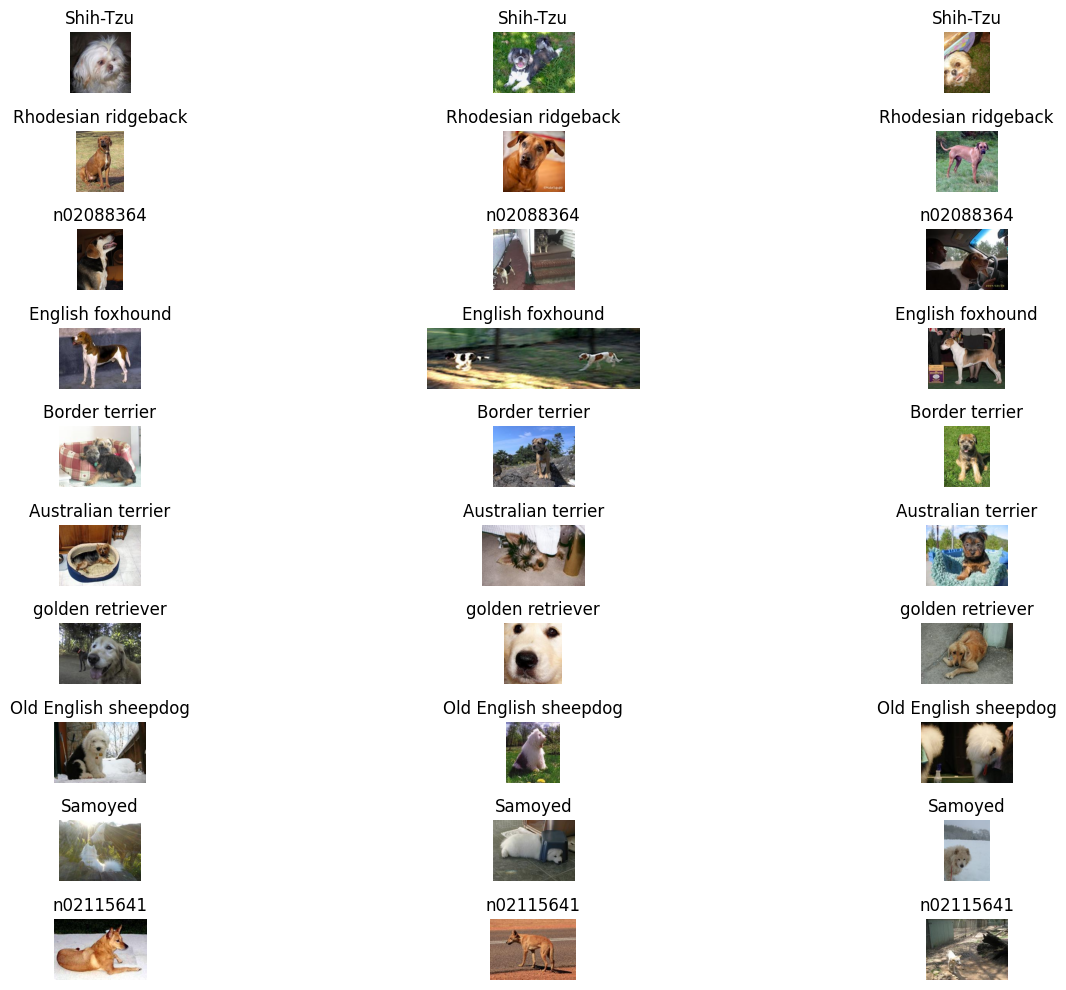

In [17]:
import random

def get_image_paths_for_class(base_path, class_id, num_images=1):
    class_path = os.path.join(base_path, class_id)
    images_in_class = [os.path.join(class_path, f) for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    return random.sample(images_in_class, min(num_images, len(images_in_class)))

num_examples_per_class = 3
plt.figure(figsize=(15, 10))

for i, class_id in enumerate(sorted(class_dirs)):
    class_name = IMAGENET_ID_TO_NAME.get(class_id, class_id)
    image_paths = get_image_paths_for_class(TRAIN_DATA_PATH, class_id, num_examples_per_class)

    for j, img_path in enumerate(image_paths):
        plt.subplot(len(class_dirs), num_examples_per_class, i * num_examples_per_class + j + 1)
        img = Image.open(img_path)
        plt.imshow(img)
        plt.title(f"{class_name}")
        plt.axis('off')

plt.tight_layout()
plt.show()

### Conclusiones y decisiones de preprocesamiento

Basándonos en el análisis exploratorio:

1.  **Distribución de clases:** Observamos que algunas clases tienen menos imágenes que otras (ej. 'English foxhound' tiene significativamente menos). Esto sugiere que el modelo podría tener un rendimiento más bajo en estas clases minoritarias, y podríamos considerar técnicas de aumento de datos o estrategias de muestreo para equilibrar el entrenamiento.

2.  **Tamaños y resoluciones de imágenes:** Todas las imágenes parecen tener un tamaño uniforme de `160x160` píxeles. Esto simplifica el preprocesamiento ya que no será necesario un redimensionamiento inicial a una misma escala, pero se podrían aplicar recortes aleatorios (random crops) como forma de *data augmentation*.

3.  **Ejemplos visuales:** Las imágenes son de perros, con variaciones en poses, fondos e iluminación. Esto refuerza la necesidad de técnicas de aumento de datos para mejorar la robustez del modelo.



## 4. Preprocesamiento y partición train / validación / test

_Transforms, augmentation y normalización, con su justificación. Separación de validación a partir de `train`._

## 5. Modelo

_Definición de la o las arquitecturas implementadas desde cero._

## 6. Entrenamiento y experimentos

_Loop de entrenamiento, logging en wandb, ablaciones de regularización y demás configuraciones probadas._

## 7. Evaluación en test

_Métricas finales del modelo elegido: accuracy, precision/recall/F1 macro y por clase, matriz de confusión y análisis de errores._

## 8. Comparación de experimentos

_Link al proyecto de wandb y tabla resumen de las corridas (configuración, métricas en validación, tiempo). Justificación del modelo final._

## 9. Conclusiones

_Qué funcionó, qué no, y qué harían distinto con más tiempo o recursos._